# EiraX UGV–UAV Swarm: End-to-End Evidence Analysis

This notebook analyses one isolated simulation run and distinguishes **software activity** from **functional evidence**. It covers mission completion, scout failover, UAV flight and landing, UGV speed/localization, ROS bag coverage, YOLO positive detections, 3D leader estimates, the distance-limited communication channel, and OMNeT++/INET.

A detector topic message is not automatically a positive detection. YOLO is considered functionally useful only when valid detections exist and the downstream 3D estimate is also produced.

In [ ]:
from pathlib import Path
import csv, json, math, os, re, subprocess
from collections import Counter, defaultdict
from datetime import datetime

os.environ.setdefault('MPLCONFIGDIR', str(Path('/tmp/eirax-matplotlib')))
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == 'analysis': ROOT = ROOT.parent
RUN_OVERRIDE = None  # Example: 'run_20260811_183229'
runs = sorted((ROOT / 'datasets').glob('run_*'), key=lambda p: p.stat().st_mtime)
RUN = ROOT / 'datasets' / RUN_OVERRIDE if RUN_OVERRIDE else runs[-1]
BAG = RUN / 'rosbag'
OUT = RUN / 'analysis_output'
OUT.mkdir(exist_ok=True)
print('Project:', ROOT)
print('Run:', RUN.name)
print('Output:', OUT)

Project: /home/basudeo/Documents/EiraX/Ruben_William_Basu/decentralized_swarm_integration
Run: run_20260811_183229
Output: /home/basudeo/Documents/EiraX/Ruben_William_Basu/decentralized_swarm_integration/datasets/run_20260811_183229/analysis_output


## 1. Run manifest and recorded-topic coverage

In [ ]:
metadata = json.loads((RUN / 'metadata.json').read_text())
role_state = json.loads((RUN / 'cooperative/swarm_role_state.json').read_text())
bag_info = subprocess.run(['/opt/ros/jazzy/bin/ros2', 'bag', 'info', str(BAG)], capture_output=True, text=True, check=True).stdout
topic_counts = {}
for line in bag_info.splitlines():
    match = re.search(r'Topic: (\S+).*Count: (\d+)', line)
    if match: topic_counts[match.group(1)] = int(match.group(2))
display(pd.DataFrame([metadata]))
display(pd.DataFrame(sorted(topic_counts.items()), columns=['topic', 'messages']))
print('Final role state:', json.dumps(role_state, indent=2))

,run_id,started_at,world_file,record_images,data_policy
0,run_20260811_183229,2026-08-11T18:32:29.184319+02:00,/tmp/eirax_cooperative_41543.world,False,real_ugv_transferable_only


,topic,messages
0,/cmd_vel,11019
1,/cmd_vel_nav,7664
2,/communication/link/distance_m,6129
3,/communication/link/quality,6129
4,/communication/link/state,6129
5,/communication/link/status,6129
6,/communication/ugv/rx/uav_odom,4134
7,/cooperative/aerial_obstacles,4130
8,/cooperative/ugv_global_path,141
9,/coord/support/uav0/leader_detection,417


Final role state: {
  "active_scout": null,
  "reason": "uav2_permanent",
  "states": {
    "uav0": "returning",
    "uav1": "returning",
    "uav2": "returning"
  },
  "term": 4
}


## 2. Mission and failover timeline
The event log is the authoritative source for waypoint completion and role transfer.

In [ ]:
events = pd.read_json(RUN / 'events.jsonl', lines=True)
events['timestamp'] = pd.to_datetime(events['timestamp'], utc=True)
events['elapsed_min'] = (events['timestamp'] - events['timestamp'].iloc[0]).dt.total_seconds() / 60
important = events[events.event.isin(['waypoint_reached','leg_completed','permanent_failure','temporary_disconnect','uav_reconnected','mission_finished'])].copy()
cols = [c for c in ['elapsed_min','component','event','target','leg','failed_uav','active_scout','term','return_code'] if c in important]
display(important[cols].fillna(''))
reached = events.loc[events.event == 'waypoint_reached', 'target'].tolist()
failovers = events.loc[events.event == 'permanent_failure', ['failed_uav','active_scout','term']].to_dict('records')
print('Reached:', reached)
print('Failovers:', failovers)

,elapsed_min,component,event,target,leg,failed_uav,active_scout,term,return_code
7,7.492690,mission,waypoint_reached,waypoint_1,,,,,
9,7.531853,cooperative_mission,leg_completed,waypoint_1,1.0,,,,
10,7.531860,failover,permanent_failure,,,uav0,uav1,2.0,
14,11.449073,mission,waypoint_reached,waypoint_2,,,,,
16,11.482511,cooperative_mission,leg_completed,waypoint_2,2.0,,,,
17,11.482519,failover,permanent_failure,,,uav1,uav2,3.0,
21,16.208012,mission,waypoint_reached,waypoint_3,,,,,
23,16.224675,cooperative_mission,leg_completed,waypoint_3,3.0,,,,
24,16.224682,failover,permanent_failure,,,uav2,,4.0,
28,19.450032,mission,waypoint_reached,goal,,,,,


Reached: ['waypoint_1', 'waypoint_2', 'waypoint_3', 'goal']
Failovers: [{'failed_uav': 'uav0', 'active_scout': 'uav1', 'term': 2.0}, {'failed_uav': 'uav1', 'active_scout': 'uav2', 'term': 3.0}, {'failed_uav': 'uav2', 'active_scout': None, 'term': 4.0}]


## 3. UAV trajectories, roles and landing accuracy

In [ ]:
trajectory_files = {'uav0': RUN/'uav_follow_trajectory.csv', 'uav1': RUN/'uav1_follow_trajectory.csv', 'uav2': RUN/'uav2_follow_trajectory.csv'}
trajectories = {name: pd.read_csv(path) for name, path in trajectory_files.items()}
landing_rows = []
fig, ax = plt.subplots(figsize=(10, 8))
for name, df in trajectories.items():
    ax.plot(df.uav_east_m, df.uav_north_m, label=name, linewidth=1)
    final = df.iloc[-1]
    landing_rows.append({'uav':name, 'samples':len(df), 'duration_s':final.elapsed_sec, 'final_phase':final.phase, 'bay_error_m':math.hypot(final.uav_north_m, final.uav_east_m), 'local_height_m':abs(final.uav_down_m)})
ax.scatter([0], [0], marker='x', s=100, color='black', label='local bay centre')
ax.set(xlabel='East (m)', ylabel='North (m)', title='PX4-local UAV trajectories'); ax.axis('equal'); ax.grid(True); ax.legend()
plt.tight_layout(); plt.savefig(OUT/'uav_trajectories.png', dpi=160); plt.show()
landing = pd.DataFrame(landing_rows)
display(landing)
landing['position_pass'] = (landing.bay_error_m <= 0.60) & (landing.local_height_m <= 0.45)
display(landing[['uav','bay_error_m','local_height_m','position_pass']])

<Figure size 1000x800 with 1 Axes>

,uav,samples,duration_s,final_phase,bay_error_m,local_height_m
0,uav0,7492,683.355,landing,0.200803,0.019
1,uav1,10250,932.556,landing,0.025020,0.004
2,uav2,13403,1230.131,landing,0.078549,0.083


,uav,bay_error_m,local_height_m,position_pass
0,uav0,0.200803,0.019,True
1,uav1,0.025020,0.004,True
2,uav2,0.078549,0.083,True


## 4. UGV trajectory, localization error and achieved speed
The configured 1.0 m/s value is a ceiling. This section estimates actual ground-truth speed from consecutive recorded poses.

{'mean_moving_mps': 0.9136301582982275, 'median_moving_mps': 0.956445442838891, 'p95_mps': 1.0007113044041682, 'max_filtered_mps': 1.2544700800011481}


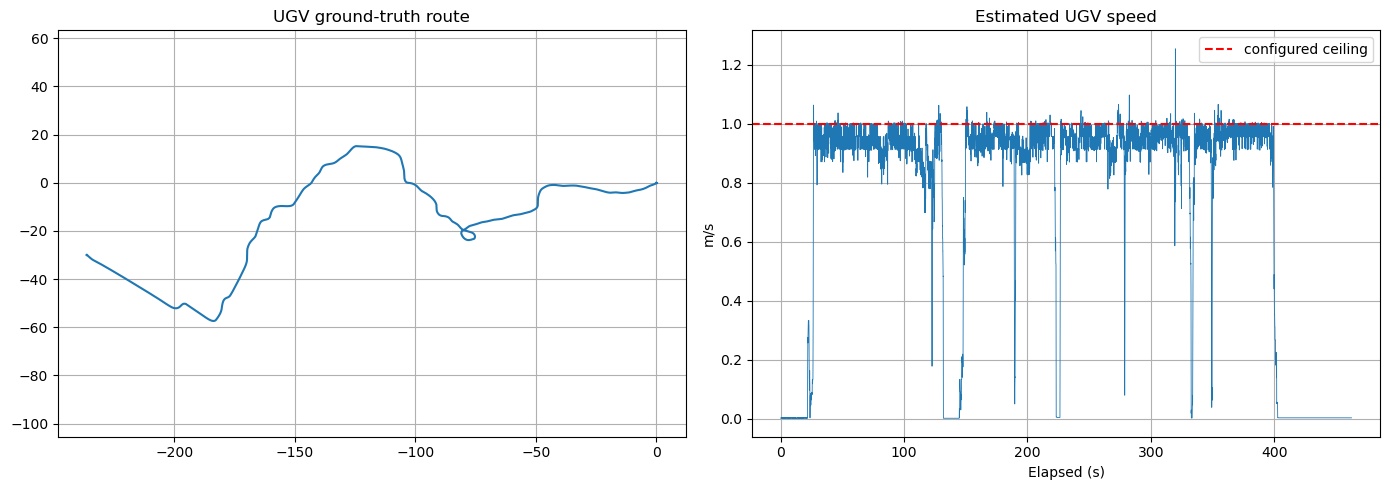

,mean,50%,95%,max
wheel_position_error,138.618084,145.569390,292.125967,292.147191
ekf_position_error,0.044287,0.042469,0.085388,0.136524
local_ekf_position_error,97.078969,86.232271,217.583246,217.593612
lidar_odom_position_error,NaN,NaN,NaN,NaN
lidar_slam_position_error,NaN,NaN,NaN,NaN
rtab_position_error,0.285594,0.241832,0.674178,0.674411


In [ ]:
loc = pd.read_csv(RUN/'localization/trajectory_and_errors.csv')
valid = loc.dropna(subset=['ground_truth_x','ground_truth_y']).copy()
dt = valid.stamp_sec.diff(); distance = ((valid.ground_truth_x.diff()**2 + valid.ground_truth_y.diff()**2)**0.5)
valid['speed_mps'] = (distance/dt).where((dt > 0.005) & (dt < 1.0)).clip(upper=5)
moving = valid.loc[valid.speed_mps > 0.05, 'speed_mps']
speed_summary = {'mean_moving_mps':moving.mean(), 'median_moving_mps':moving.median(), 'p95_mps':moving.quantile(.95), 'max_filtered_mps':moving.max()}
print(speed_summary)
fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].plot(valid.ground_truth_x, valid.ground_truth_y); axes[0].set_title('UGV ground-truth route'); axes[0].axis('equal'); axes[0].grid(True)
axes[1].plot(valid.stamp_sec-valid.stamp_sec.iloc[0], valid.speed_mps, linewidth=.6); axes[1].axhline(1.0,color='red',linestyle='--',label='configured ceiling'); axes[1].set(xlabel='Elapsed (s)',ylabel='m/s',title='Estimated UGV speed'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.savefig(OUT/'ugv_route_speed.png',dpi=160); plt.show()
error_cols=[c for c in valid.columns if c.endswith('_position_error')]
display(valid[error_cols].describe(percentiles=[.5,.95]).T[['mean','50%','95%','max']])

## 5. YOLO payload evidence from the MCAP bag
This reads the actual `std_msgs/String` payloads. `valid=true` means the detector returned a box. It still does not establish correct classification without ground-truth labels or visual inspection. A nonzero `leader_estimate` count is required to demonstrate downstream 3D fusion.

In [ ]:
import rosbag2_py
from rclpy.serialization import deserialize_message
from rosidl_runtime_py.utilities import get_message

wanted = {f'/coord/support/uav{i}/leader_detection' for i in range(3)} | {f'/coord/support/uav{i}/leader_detection_status' for i in range(3)} | {'/coord/swarm/semantic_observations'}
reader = rosbag2_py.SequentialReader()
reader.open(rosbag2_py.StorageOptions(uri=str(BAG), storage_id='mcap'), rosbag2_py.ConverterOptions('cdr','cdr'))
types = {x.name:x.type for x in reader.get_all_topics_and_types()}
rows=[]
while reader.has_next():
    topic, raw, stamp = reader.read_next()
    if topic not in wanted: continue
    msg = deserialize_message(raw, get_message(types[topic]))
    rows.append({'topic':topic,'bag_stamp_ns':stamp,'data':msg.data})
bag_payloads=pd.DataFrame(rows)
bag_payloads.to_csv(OUT/'selected_string_topics.csv',index=False)
print('Extracted payloads:',len(bag_payloads))

Extracted payloads: 2599


,messages,positive_detections,positive_rate,mean_positive_confidence,leader_estimate_messages
uav,,,,,
uav0,417,24,0.057554,0.253309,0
uav1,368,119,0.323370,0.447362,0
uav2,391,103,0.263427,0.317112,0


,uav,class_name,count
0,uav0,ugv,24
1,uav1,ugv,119
2,uav2,ugv,103


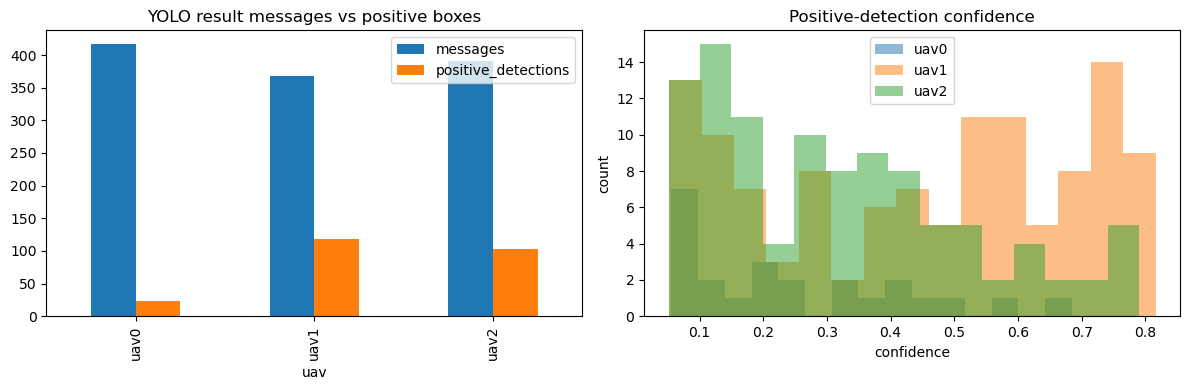

In [ ]:
detections=[]
for row in bag_payloads[bag_payloads.topic.str.endswith('/leader_detection')].itertuples():
    uav=re.search(r'/(uav\d+)/',row.topic).group(1)
    try:
        payload=json.loads(row.data)
        detections.append({'uav':uav,'valid':bool(payload.get('valid')),'confidence':payload.get('conf'),'class_name':payload.get('cls_name',''),'source':payload.get('source',''),'track_id':payload.get('track_id'),'stamp_ns':payload.get('stamp_ns',0)})
    except Exception:
        detections.append({'uav':uav,'valid':False,'confidence':None,'class_name':'DECODE_ERROR','source':'','track_id':None,'stamp_ns':0})
det=pd.DataFrame(detections)
summary=det.groupby('uav').agg(messages=('valid','size'),positive_detections=('valid','sum'),positive_rate=('valid','mean'),mean_positive_confidence=('confidence',lambda x:pd.to_numeric(x,errors='coerce')[det.loc[x.index,'valid']].mean()))
summary['leader_estimate_messages']=[topic_counts.get(f'/coord/support/{u}/leader_estimate',0) for u in summary.index]
display(summary)
display(det[det.valid].groupby(['uav','class_name']).size().rename('count').reset_index())
fig,axes=plt.subplots(1,2,figsize=(12,4))
summary[['messages','positive_detections']].plot.bar(ax=axes[0],title='YOLO result messages vs positive boxes')
for uav,g in det[det.valid].groupby('uav'): axes[1].hist(pd.to_numeric(g.confidence),bins=15,alpha=.5,label=uav)
axes[1].set(title='Positive-detection confidence',xlabel='confidence',ylabel='count'); axes[1].legend(); plt.tight_layout(); plt.savefig(OUT/'yolo_evidence.png',dpi=160); plt.show()

## 6. Distance-limited ROS communication channel

,mode,started_at,finished_at,duration_sec,maximum_range_m,maximum_observed_distance_m,warning_range_m,reconnect_range_m,link_uptime_ratio,total_packets,total_bytes,total_delivered_packets,total_dropped_packets,delivery_ratio
0,distance_limited,2026-08-11T16:32:32.682988+00:00,2026-08-11T16:59:10.638468+00:00,1597.954549,50.0,247.595402,40.0,45.0,0.306189,48506,239960936,14852,33654,0.306189


,flow,direction,packet_count,delivered_packet_count,dropped_packet_count,delivery_ratio,mean_latency_ms,maximum_latency_ms,mean_throughput_kbps
0,ugv_gnss,UGV_TO_UAV,5849,1568,4281,0.26808,0.1621,3.126931,4.363083
1,ugv_odometry,UGV_TO_UAV,17397,4702,12695,0.270276,0.185682,13.95058,63.057753
2,ugv_global_path,UGV_TO_UAV,465,141,324,0.303226,13.660972,33.514147,151.079441
3,uav_aerial_obstacles,UAV_TO_UGV,17047,4219,12828,0.247492,0.239459,12.394514,954.446226
4,uav_odometry,UAV_TO_UGV,7748,4222,3526,0.544915,0.223112,18.197318,28.393979


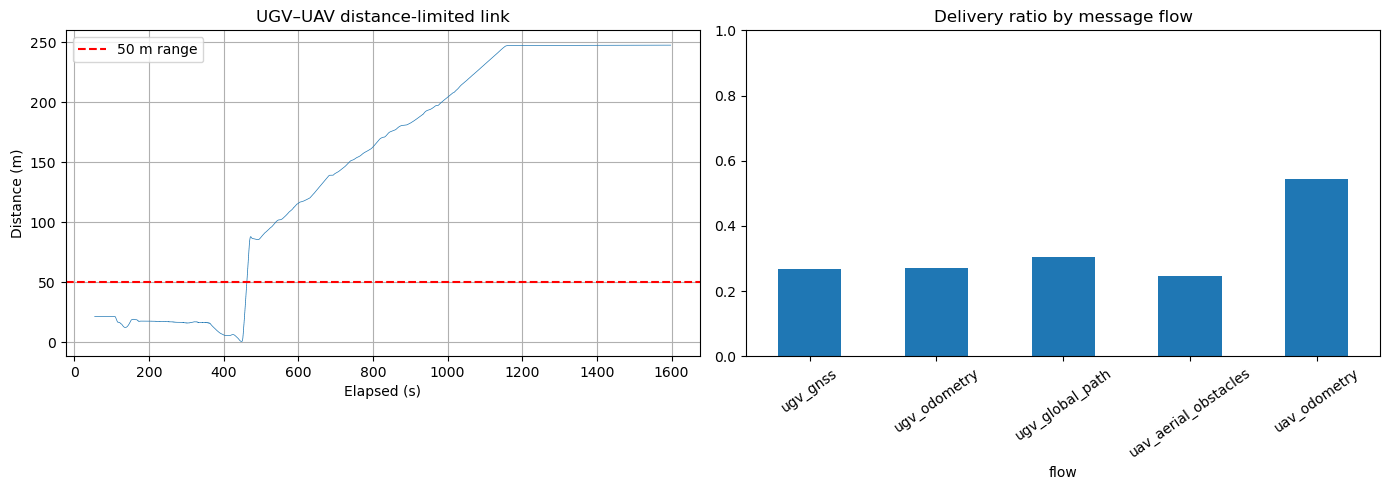

In [ ]:
network_summary=json.loads((RUN/'communication/communication_summary.json').read_text())
flows=pd.DataFrame(network_summary['flows']).T.reset_index(names='flow')
display(pd.DataFrame([{k:v for k,v in network_summary.items() if k not in ['flows','radio_metrics','security_metrics']}]))
display(flows[['flow','direction','packet_count','delivered_packet_count','dropped_packet_count','delivery_ratio','mean_latency_ms','maximum_latency_ms','mean_throughput_kbps']])
net=pd.read_csv(RUN/'communication/communication_events.csv')
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].plot(net.elapsed_sec,net.distance_m,linewidth=.5); axes[0].axhline(network_summary['maximum_range_m'],color='red',linestyle='--',label='50 m range'); axes[0].set(xlabel='Elapsed (s)',ylabel='Distance (m)',title='UGV–UAV distance-limited link'); axes[0].legend(); axes[0].grid(True)
flows.plot.bar(x='flow',y='delivery_ratio',ax=axes[1],legend=False,title='Delivery ratio by message flow'); axes[1].set_ylim(0,1); axes[1].tick_params(axis='x',rotation=35)
plt.tight_layout(); plt.savefig(OUT/'communication_channel.png',dpi=160); plt.show()

## 7. OMNeT++/INET evidence
This is a separate network overlay. Its scalar output demonstrates simulated transmissions/receptions, but it must not be confused with the ROS distance-limited channel above.

In [ ]:
sca=ROOT/'omnet/results/General-#0.sca'
scalar_rows=[]
if sca.exists():
    for line in sca.read_text(errors='replace').splitlines():
        if line.startswith('scalar '):
            parts=line.split(maxsplit=3)
            if len(parts)==4:
                try: value=float(parts[3])
                except ValueError: continue
                scalar_rows.append({'module':parts[1],'metric':parts[2],'value':value})
scalars=pd.DataFrame(scalar_rows)
print('Scalar file:',sca,'rows:',len(scalars))
display(scalars[scalars.metric.str.contains('packet|received|sent|drop|throughput|delay',case=False,regex=True)].head(100) if len(scalars) else scalars)
omnet_log=max((ROOT/'runtime_logs').glob('*_omnet.log'),key=lambda p:p.stat().st_mtime)
text=omnet_log.read_text(errors='replace')
received={int(i):int(n) for i,n in re.findall(r'uav\[(\d+)\]\.app\[0\]: received (\d+) packets',text)}
print('Latest OMNeT log:',omnet_log.name)
print('Packets received by UAV application:',received)

Scalar file: /home/basudeo/Documents/EiraX/Ruben_William_Basu/decentralized_swarm_integration/omnet/results/General-#0.sca rows: 506


,module,metric,value
1,EiraXSwarmNetwork.ugv.lo[0].lo,rcvdPkFromHl:sum(packetBytes),0.0
3,EiraXSwarmNetwork.ugv.lo[0].lo,passedUpPk:sum(packetBytes),0.0
4,EiraXSwarmNetwork.ugv.lo[0],packetDropInterfaceDown:count,0.0
5,EiraXSwarmNetwork.ugv.lo[0],packetDropInterfaceDown:sum(packetBytes),0.0
6,EiraXSwarmNetwork.ugv.lo[0],packetDropNoCarrier:count,0.0
...,...,...,...
118,EiraXSwarmNetwork.ugv.udp,packetSent:sum(packetBytes),22738560.0
120,EiraXSwarmNetwork.ugv.udp,droppedPkWrongPort:count,0.0
121,EiraXSwarmNetwork.ugv.udp,droppedPkBadChecksum:count,0.0
122,EiraXSwarmNetwork.ugv.app[0],packetReceived:count,0.0


Latest OMNeT log: 20260811_183226_omnet.log
Packets received by UAV application: {0: 14576, 1: 14576, 2: 14576}


## 8. Evidence verdict and showcase checklist

In [ ]:
checks=[]
def check(area,claim,passed,evidence): checks.append({'area':area,'claim':claim,'passed':bool(passed),'evidence':evidence})
check('Mission','UGV reached all four targets',reached==['waypoint_1','waypoint_2','waypoint_3','goal'],str(reached))
check('Failover','UAV0→UAV1→UAV2→Nav2 sequence occurred',len(failovers)==3 and role_state.get('active_scout') is None,json.dumps(failovers))
check('Landing position','All UAVs returned within 0.60 m and <=0.45 m height',landing.position_pass.all(),landing[['uav','bay_error_m','local_height_m']].to_dict('records'))
final_code=events.loc[events.event=='mission_finished','return_code'].iloc[-1] if any(events.event=='mission_finished') else None
check('Landing completion','PX4 accepted disarm and mission returned zero',final_code==0,f'return_code={final_code}')
check('YOLO execution','Detector published result messages',summary.messages.sum()>0,f'{summary.messages.sum()} messages')
check('YOLO positive output','At least one valid detection exists',summary.positive_detections.sum()>0,f'{summary.positive_detections.sum()} positive')
check('YOLO 3D integration','At least one 3D leader estimate exists',summary.leader_estimate_messages.sum()>0,f'{summary.leader_estimate_messages.sum()} estimates')
check('ROS communication','Communication events and flow metrics recorded',network_summary['total_packets']>0,f"{network_summary['total_packets']} packets, {network_summary['delivery_ratio']:.1%} delivered")
check('OMNeT++','Each UAV application received packets',len(received)==3 and all(v>0 for v in received.values()),str(received))
verdict=pd.DataFrame(checks)
display(verdict.style.map(lambda x:'background-color:#c6efce' if x is True else ('background-color:#ffc7ce' if x is False else ''),subset=['passed']))
verdict.to_csv(OUT/'evidence_verdict.csv',index=False)
print('Passed',int(verdict.passed.sum()),'of',len(verdict),'evidence gates')
print('Figures and tables saved to',OUT)

,area,claim,passed,evidence
0,Mission,UGV reached all four targets,True,"['waypoint_1', 'waypoint_2', 'waypoint_3', 'goal']"
1,Failover,UAV0→UAV1→UAV2→Nav2 sequence occurred,True,"[{""failed_uav"": ""uav0"", ""active_scout"": ""uav1"", ""term"": 2.0}, {""failed_uav"": ""uav1"", ""active_scout"": ""uav2"", ""term"": 3.0}, {""failed_uav"": ""uav2"", ""active_scout"": null, ""term"": 4.0}]"
2,Landing position,All UAVs returned within 0.60 m and <=0.45 m height,True,"[{'uav': 'uav0', 'bay_error_m': 0.20080338642562778, 'local_height_m': 0.019}, {'uav': 'uav1', 'bay_error_m': 0.02501999200639361, 'local_height_m': 0.004}, {'uav': 'uav2', 'bay_error_m': 0.07854934754662192, 'local_height_m': 0.083}]"
3,Landing completion,PX4 accepted disarm and mission returned zero,False,return_code=3.0
4,YOLO execution,Detector published result messages,True,1176 messages
5,YOLO positive output,At least one valid detection exists,True,246 positive
6,YOLO 3D integration,At least one 3D leader estimate exists,False,0 estimates
7,ROS communication,Communication events and flow metrics recorded,True,"48506 packets, 30.6% delivered"
8,OMNeT++,Each UAV application received packets,True,"{0: 14576, 1: 14576, 2: 14576}"


Passed 7 of 9 evidence gates
Figures and tables saved to /home/basudeo/Documents/EiraX/Ruben_William_Basu/decentralized_swarm_integration/datasets/run_20260811_183229/analysis_output


## Interpretation rules for a thesis/demo

- Say **YOLO ran** if detector result topics contain messages.
- Say **YOLO detected the target** only if decoded payloads contain `valid=true`, supported by confidence/class distributions and preferably annotated images or labelled ground truth.
- Say **YOLO informed cooperation/navigation** only if valid 3D leader estimates or another documented downstream consumer acted on those detections.
- Report the ROS distance-limited channel and OMNeT++/INET overlay separately; they currently measure different layers.
- Treat return-to-bay position and successful PX4 disarm as two separate landing requirements.